In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv("Data/allyears.csv", index_col="id")
df["date"] = pd.to_datetime(df["date"])
df["client"] = df["client"].str.lower()
df["client"] = df["client"].str.strip()
df["client"] = df["client"].str.title()


cdf = (
    df.groupby("client")["date"]
    .agg(count="count", first_time="min", last_time="max")
    .reset_index()
)

cdf["months"] = (
    cdf["last_time"].dt.to_period("M") - cdf["first_time"].dt.to_period("M")
).apply(lambda x: x.n)

print(cdf)


                   client  count first_time  last_time  months
0                 A Chris      1 2025-09-09 2025-09-09       0
1           Aaron Ornelas      1 2024-03-01 2024-03-01       0
2           Abby Trujillo      1 2025-04-16 2025-04-16       0
3     Abdelaziz Aboelseud      4 2025-02-14 2025-05-15       3
4          Abigail Barney      6 2025-01-11 2025-11-06      10
...                   ...    ...        ...        ...     ...
2483         Zeke Tripodi     15 2024-04-24 2025-11-07      19
2484         Zina Salcedo      1 2025-12-04 2025-12-04       0
2485        Zoie Langford     51 2024-01-03 2025-12-16      23
2486    Zoie Langford (R)      2 2025-09-26 2025-10-28       1
2487      Zullany Padilla      5 2024-10-22 2025-01-16       3

[2488 rows x 5 columns]


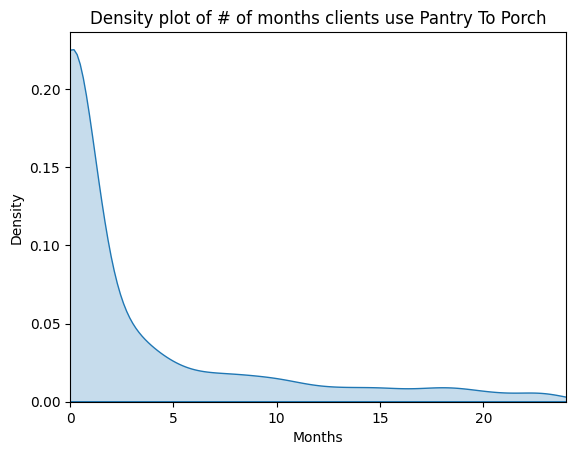

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
sns.kdeplot(cdf["months"], ax=ax, fill=True)
ax.set_xlim(0,24)
ax.set_title("Density plot of # of months clients use Pantry To Porch")
ax.set_xlabel("Months")

fig.savefig("Visuals/jon-months-density.png", dpi=500)

<BarContainer object of 1 artists>

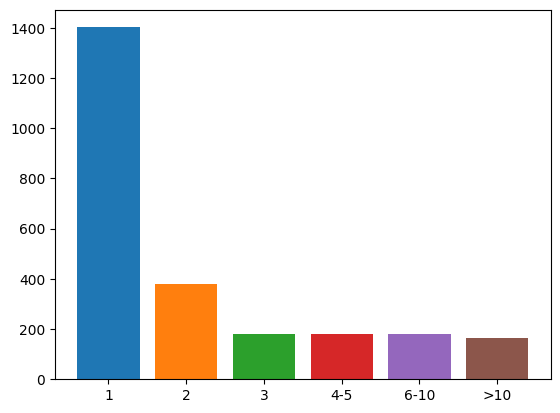

In [20]:
# bar plot

fig, ax = plt.subplots()

ax.bar("1" , len(cdf[cdf["count"] == 1]))
ax.bar("2" , len(cdf[cdf["count"] == 2]))
ax.bar("3" , len(cdf[cdf["count"] == 3]))
ax.bar("4-5" , len(cdf[(cdf["count"] >= 4) & (cdf["count"] <= 5)]))
ax.bar("6-10" , len(cdf[(cdf["count"] >= 6) & (cdf["count"] <= 10)]))
ax.bar(">10" , len(cdf[cdf["count"] > 10]))